# Diagnostics and Prediction

This notebook section evaluates the home run prediction models by examining posterior diagnostics, predictive accuracy, and classification performance. Posterior trace plots and summaries are used to check MCMC convergence and quantify uncertainty in parameter estimates, while PSIS-LOO provides an approximation of out-of-sample predictive accuracy and flags influential observations. To assess classifier quality, predictions are thresholded to calculate precision, recall, and alert volumes, with thresholds chosen to balance false positives and missed home runs. Finally, the model is applied for prediction by computing rolling features such as barrel rate up to game t and feeding them, along with covariates and random/fixed effects, into the posterior to generate matchup-level home run probabilities.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import arviz as az

In [2]:
# Find the repo root by searching upwards for src/hrmodel
here = Path.cwd()
for p in (here, *here.parents):
    if (p / "src" / "hrmodel").exists():
        REPO = p
        break
else:
    raise RuntimeError("Could not find repo root containing src/hrmodel")

# Put src/ on sys.path (front so it wins)
sys.path.insert(0, str(REPO / "src"))

# Import from your package
from hrmodel import (
    #load_idata_and_preds,
    get_latest_batter_pitcher_data,
    plot_trace_summary,
    summarize_posterior, 
    sweep_thresholds,
    pick_by_precision_floor,
    posterior_hr_prob,
    plot_hr_prob
)

from hrmodel.utils.paths import list_runs, load_variant
from hrmodel.utils.metrics import (
    log_and_save_posterior_summary, 
    log_and_save_model_comparison, 
    log_and_save_threshold_tables
)
from hrmodel.utils.logging_utils import RunLogger

### Loading Model

In [3]:
idata_full,  y_true, p_full,  run_dir_full  = load_variant("full")
idata_nprev, _,      p_nprev, run_dir_nprev = load_variant("noprev")
print(run_dir_full.name, run_dir_nprev.name)

2025-10-04_02 2025-10-04_02


In [4]:
# Load the at-bats dataset 
at_bats_2025 = pd.read_csv("data/at_bats_2025.csv")

# Assign unique indices
at_bats_2025["batter_idx"] = at_bats_2025["batter_name"].astype("category").cat.codes
at_bats_2025["pitcher_idx"] = at_bats_2025["pitcher_name"].astype("category").cat.codes
at_bats_2025["ballpark_idx"] = at_bats_2025["home_team"].astype("category").cat.codes

hand_num = at_bats_2025["p_throws"].map({"R": 0, "L": 1}).fillna(0).values
at_bats_2025["hand_num"] = hand_num

at_bats_2025.head()

,game_date,pitcher_name,home_team,away_team,inning,inning_topbot,at_bat_number,batter_name,batter_id,pitch_number,...,starting_pitcher,barrel,rolling_batter_barrel_rate,rolling_pitcher_barrel_rate,home_run,prev_game_hr,batter_idx,pitcher_idx,ballpark_idx,hand_num
0,2025-03-18,"Buehler, Walker",NYY,BOS,1,Bot,6,Aaron Judge,592450,4,...,1,0,0.152080,0.000000,0,0,0,130,19,0
1,2025-03-18,"Buehler, Walker",NYY,BOS,4,Bot,25,Aaron Judge,592450,3,...,1,1,0.000000,0.200000,0,0,0,130,19,0
2,2025-03-18,"Buehler, Walker",NYY,BOS,5,Bot,37,Aaron Judge,592450,4,...,1,0,0.500000,0.210526,0,0,0,130,19,0
3,2025-03-19,"Schwellenbach, Spencer",NYY,ATL,1,Bot,6,Aaron Judge,592450,4,...,1,0,0.333333,0.000000,0,0,0,843,19,0
4,2025-03-19,"Schwellenbach, Spencer",NYY,ATL,4,Bot,25,Aaron Judge,592450,3,...,1,0,0.250000,0.000000,0,0,0,843,19,0


## Diagnostics

### Posterior Trace Plots

The figure below shows trace plots and posterior densities for the key model parameters. These plots are useful for assessing MCMC convergence and visualizing the posterior distributions. Stable chains without strong trends or divergences indicate good mixing, while the density plots summarize the estimated parameter values.

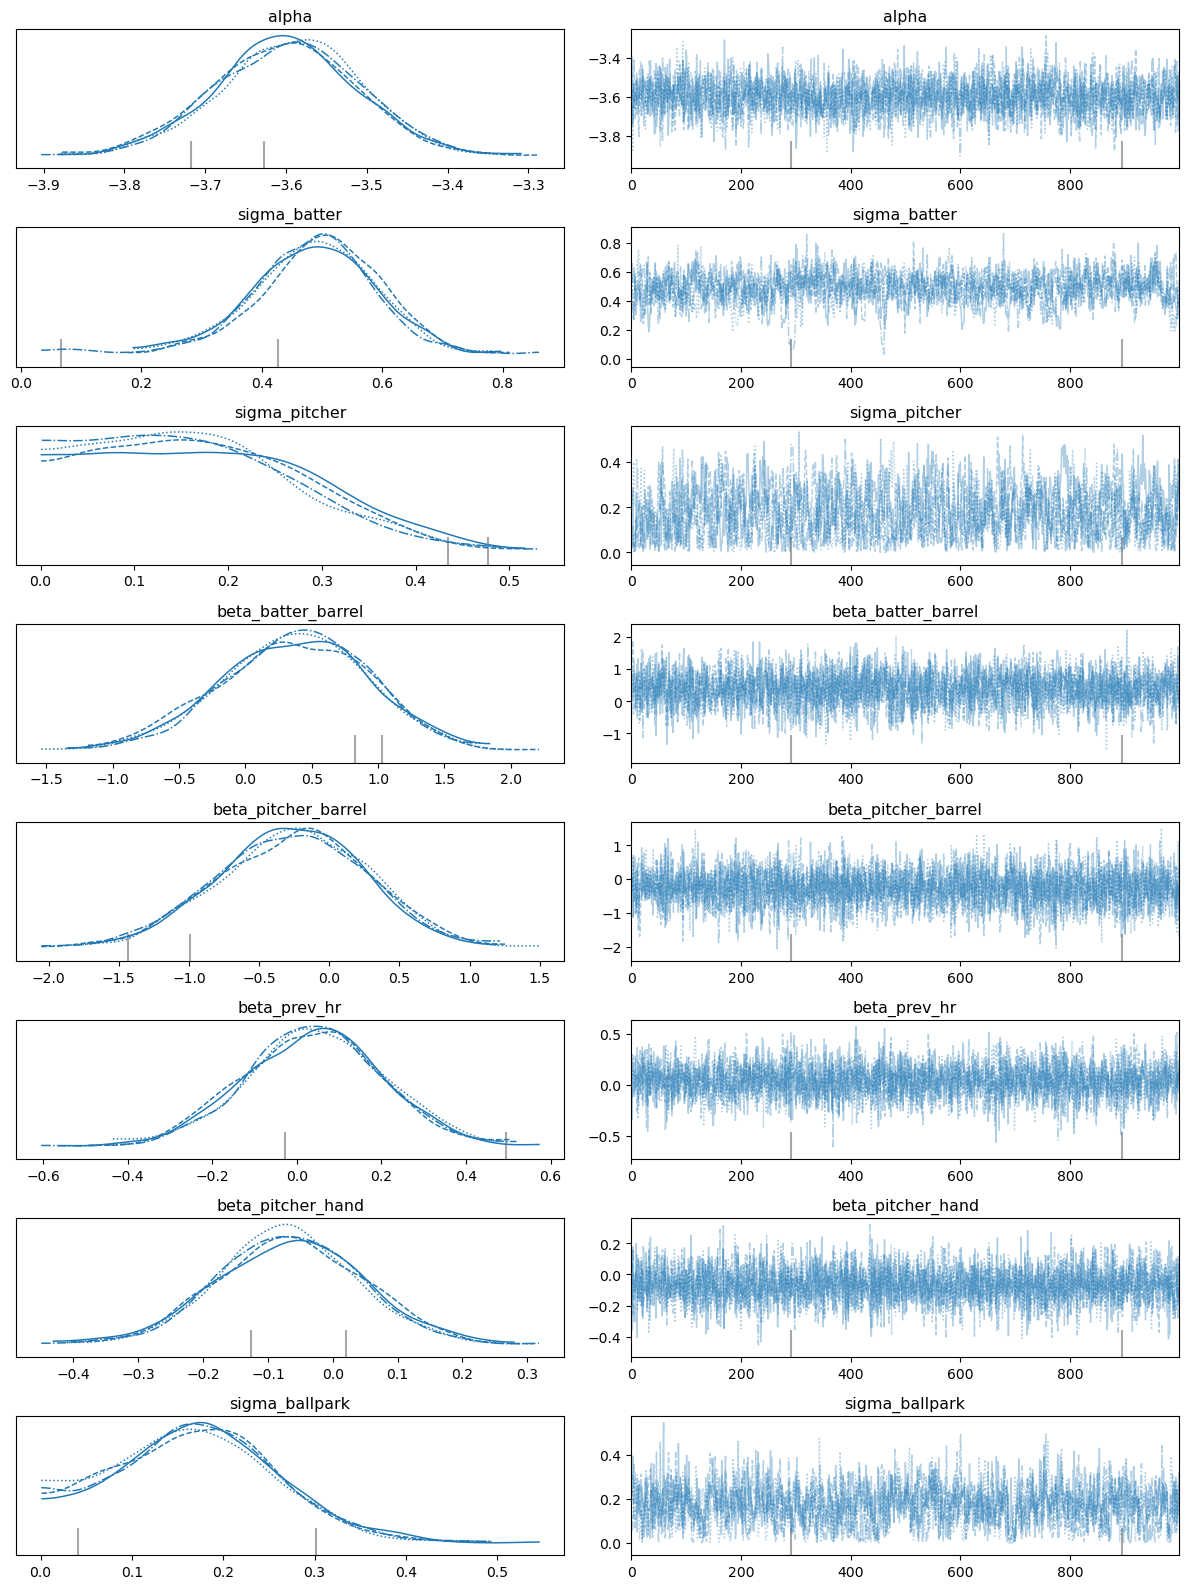

In [5]:
var_names = [
    "alpha",
    "sigma_batter",
    "sigma_pitcher",
    "beta_batter_barrel",
    "beta_pitcher_barrel",
    "beta_prev_hr",
    "beta_pitcher_hand",
    "sigma_ballpark",
]


plot_trace_summary(idata_full, var_names=var_names)

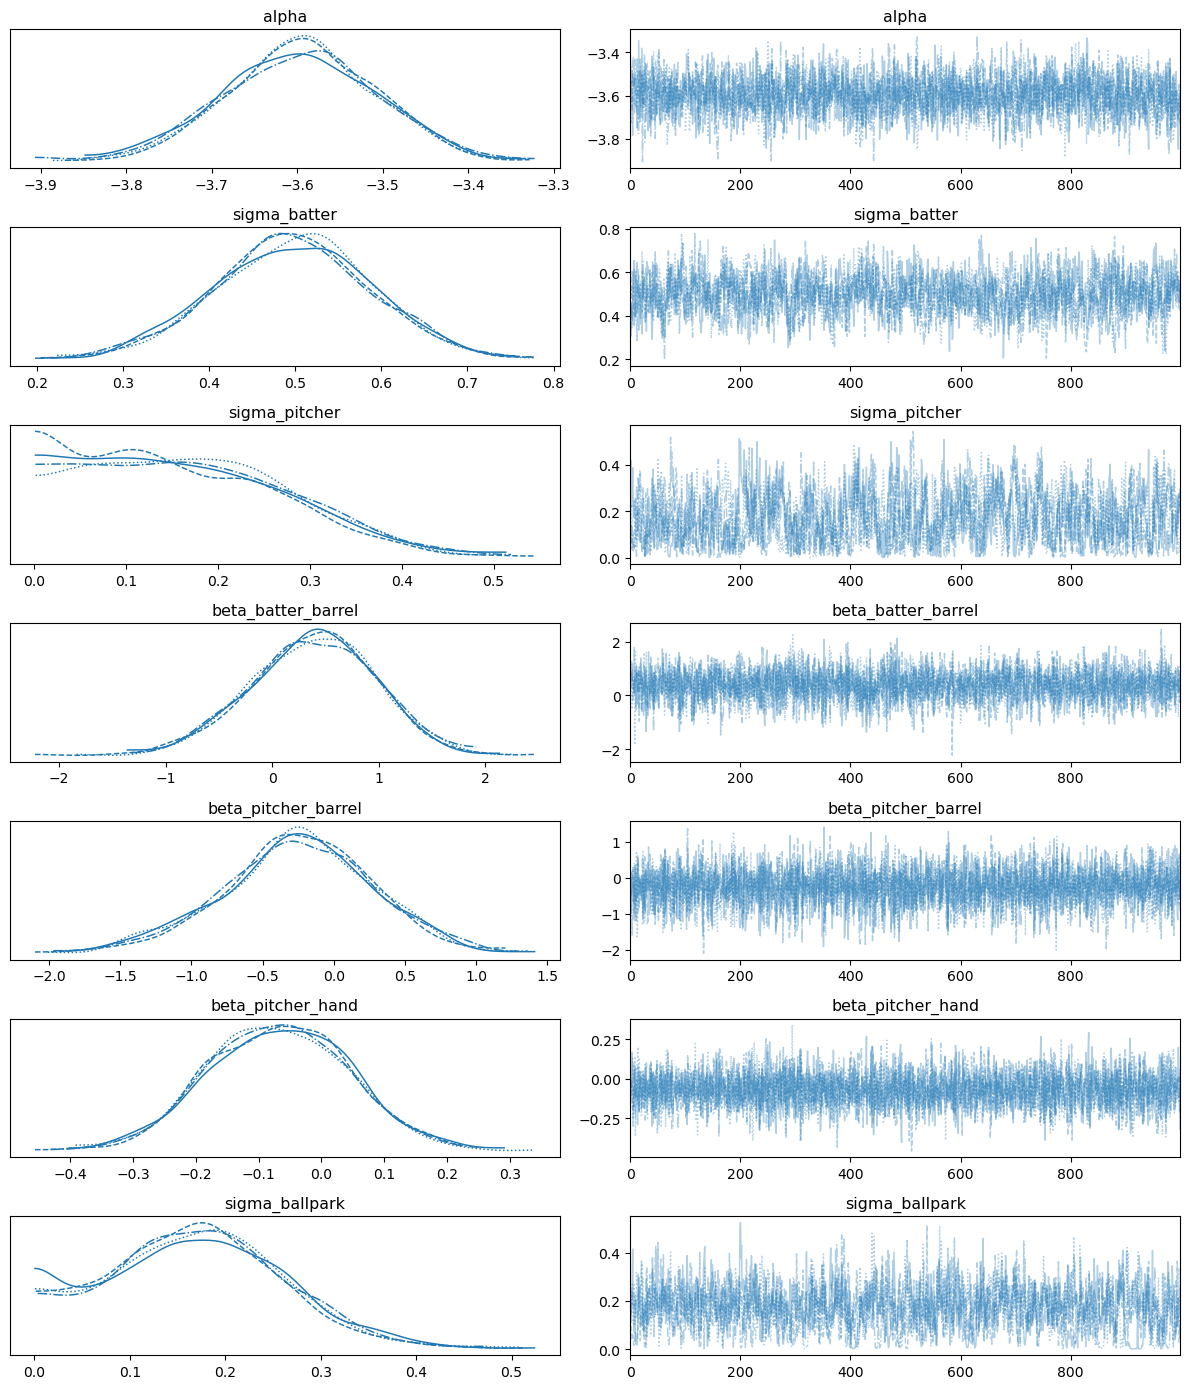

In [6]:
plot_trace_summary(
    idata_nprev,
    var_names=[v for v in var_names if v in idata_nprev.posterior.data_vars]
)

### Posterior Summary

The table below reports posterior means, standard deviations, and 95% credible intervals for the main model coefficients. The 95% credible interval represents the range within which the parameter lies with 95% posterior probability, providing a measure of uncertainty around each effect estimate.

In [7]:
# FULL
full_posterior_summary = summarize_posterior(idata_full, var_names=var_names)
full_posterior_summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-3.599,0.088,-3.775,-3.432,0.002,0.001,2273.671,2784.743,1.000
sigma_batter,0.487,0.102,0.273,0.674,0.004,0.003,713.218,787.384,1.003
sigma_pitcher,0.173,0.108,0.000,0.369,0.004,0.003,647.070,1317.983,1.003
beta_batter_barrel,0.371,0.546,-0.689,1.439,0.010,0.007,2818.490,3054.236,1.001
beta_pitcher_barrel,-0.265,0.534,-1.281,0.780,0.008,0.008,3994.426,2967.604,1.001
beta_prev_hr,0.040,0.163,-0.290,0.345,0.003,0.002,2511.937,2599.581,1.001
beta_pitcher_hand,-0.067,0.111,-0.278,0.162,0.002,0.002,4824.518,3027.903,1.003
sigma_ballpark,0.169,0.088,0.000,0.316,0.003,0.002,883.863,1102.313,1.004


In [8]:
# FULL
log_and_save_posterior_summary(runlog=None, summary_df=full_posterior_summary, variant="full")

PosixPath('artifacts/logs/2025-10-04_02/full/posterior_summary.csv')

In [9]:
# NO PREVIOUS HR
nprev_posterior_summary = summarize_posterior(idata_nprev, 
                                     var_names=[v for v in var_names if v in idata_nprev.posterior.data_vars]
)

nprev_posterior_summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-3.596,0.089,-3.770,-3.426,0.002,0.001,2363.193,3071.793,1.002
sigma_batter,0.497,0.090,0.311,0.666,0.003,0.002,1046.780,1868.203,1.002
sigma_pitcher,0.168,0.108,0.000,0.358,0.004,0.003,577.381,1155.095,1.011
beta_batter_barrel,0.382,0.579,-0.821,1.429,0.010,0.008,3254.922,2674.610,1.002
beta_pitcher_barrel,-0.255,0.524,-1.318,0.774,0.007,0.007,5469.637,2897.405,1.000
beta_pitcher_hand,-0.068,0.111,-0.297,0.137,0.002,0.001,4611.938,2620.314,1.001
sigma_ballpark,0.170,0.090,0.000,0.322,0.003,0.002,684.835,621.678,1.003


In [10]:
# NO PREVIOUS HR
log_and_save_posterior_summary(runlog=None, summary_df=full_posterior_summary, variant="noprev")

PosixPath('artifacts/logs/2025-10-04_02/noprev/posterior_summary.csv')

### Model: LOO and Posterior Predictive

LOO estimates out-of-sample predictive accuracy by approximating leave-one-out cross-validation from a single posterior fit. In practice, ArviZ’s PSIS-LOO takes the posterior log-likelihood draws for each observation, applies Pareto-smoothed importance sampling to approximate the refit that would occur if that observation were omitted, and aggregates the per-observation contributions into the expected log pointwise predictive density, `elpd_loo` (larger is better). It also reports diagnostics such as Pareto-$k$, which flag influential observations where the approximation is less reliable.

Since the data has over 100,000 observations, using the full PSIS-LOO is memory-intensive because the log-likelihood tensor scales with chains × draws × observations. To keep computation tractable while preserving a faithful comparison, the following was done:

- Retain all chains but thin the MCMC draws by using every 5th draw
- Down-cast log-likelihood to float32, which halves memory usage with negligible impact on model ranking
- Use a minimal object for LOO by providing only the `log_likelihood` to PSIS-LOO, omitting other posterior groups.
-  **Provide and justify relative efficiency:** because the posterior group is absent, pass a scalar $\text{reff}$ so ArviZ can proceed; $\text{reff} = \frac{\text{ESS}}{N}$ summarizes how many independent draws the sample effectively contains after autocorrelation. Setting $\text{reff} = 1.0$ assumes near-independent draws and chiefly affects uncertainty (standard errors) and diagnostics rather than the ELPD point estimates.


In [11]:
ll_n = idata_nprev.log_likelihood["y_obs"].sel(chain=[0,1,2,3], draw=slice(None, None, 5)).astype("float32")
ll_f = idata_full.log_likelihood["y_obs"].sel(chain=[0,1,2,3], draw=slice(None, None, 5)).astype("float32")

loo_n = az.loo(az.from_dict(log_likelihood={"y_obs": ll_n}), pointwise=True, reff=1.0)
loo_f = az.loo(az.from_dict(log_likelihood={"y_obs": ll_f}), pointwise=True, reff=1.0)

In [12]:
# now compare works
comp = az.compare({"noprev": loo_n, "full": loo_f}, ic="loo")
comp


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
noprev,0,-2028.015043,108.490190,0.000000,1.0,71.914881,0.000000,False,log
full,1,-2029.007619,108.406922,0.992576,0.0,72.050527,0.693831,False,log


In [13]:
log_and_save_model_comparison(
    runlog=None,                 # auto target latest logs run
    comp_df=comp,                # use the DataFrame you computed
    ic="loo",                    # so the filename becomes comparison_loo.csv
)

(PosixPath('artifacts/logs/2025-10-04_02/comparison/comparison_loo.csv'),
         rank     elpd_loo       p_loo  elpd_diff  weight         se       dse  \
 noprev     0 -2028.015043  108.490190   0.000000     1.0  71.914881  0.000000   
 full       1 -2029.007619  108.406922   0.992576     0.0  72.050527  0.693831   
 
         warning scale  
 noprev    False   log  
 full      False   log  )

## Accuracy Metrics

To evaluate the classifier, focus on precision, recall, and the resulting alert volume at a chosen probability threshold $t$. Precision and recall are defined as

$$
\text{Precision}=\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}},\qquad
\text{Recall}=\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}\,,
$$
where:
- **TP** = true positives (home runs correctly classified as home runs)  
- **FP** = false positives (non–home runs incorrectly classified as home runs)  
- **FN** = false negatives (home runs incorrectly classified as non–home runs)

Each plate appearance has a predicted home-run probability $p_i$. An at-bat is classified as a home run when $p_i \ge t$, where $t$ is the decision threshold.

**Alerts.** At threshold $t$, alerts are the number of plate appearances flagged positive:

$$
\text{Alerts}=\sum_{i=1}^{N}\mathbf{1}[\,p_i \ge t\,] \;=\; \mathrm{TP}+\mathrm{FP}.
$$

- $\mathbf{1}[\cdot]$ = indicator (1 if the condition is true, 0 otherwise)

Alerts depend only on the predictions and the chosen threshold $t$. The split into $\mathrm{TP}$ and $\mathrm{FP}$ requires ground-truth labels.

*Because home runs are rare, thresholds below $0.5$ are often used to balance precision, recall, and alert volume.*


Below, we will evaluate the metrics at various threshold and minimum precision levels, using the following steps:

1. **Build a threshold grid.**  
   Create a sequence of candidate probability cutoffs $t \in [0.03, 0.08]$ in increments of $0.001$. For each $t$, predictions are $\mathbf{1}[p_i \ge t]$.

2. **Sweep performance across thresholds.**  
   For every $t$ in the grid, compute the **precision**, **recall**, and **alerts** as defined above and collect counts **TP**, **FP**, **FN**.

3. **Specify candidate precision floors.**  
   Choose target precision levels between $0.070$ and $0.090$ in increments of $0.005$ that encode a minimum acceptable alert quality.

4. **Select an operating point per floor.**  
   For each floor $f$, pick the threshold $t^*$ that meets/exceeds the floor,
   $
   \text{Precision} \ge f,
   $
   and among feasible thresholds **maximizes recall**, using a tie-break rule if needed.


The resulting DataFrame summarizes, for each precision floor, the chosen $t^*$ and the corresponding precision, recall, alerts, TP, FP, FN, and a flag `met_floor` indicating whether the floor was actually satisfied.


**Sources**

https://www.nb-data.com/p/understanding-f-beta-for-model-evaluation

https://medium.com/@piyushkashyap045/understanding-precision-recall-and-f1-score-metrics-ea219b908093

In [14]:
# 1) Sweep thresholds once
ths   = np.linspace(0.03, 0.08, 51)
sweep = sweep_thresholds(y_true, {"noprev": p_nprev}, ths)

# 2) Try a few candidate precision floors and see recall/alerts
floors = np.linspace(0.07, 0.09, 9)
choices = [pick_by_precision_floor(sweep, floor=f).assign(floor=f) for f in floors]
choices = pd.concat(choices)
choices

,threshold,precision,recall,alerts,tp,fp,fn,floor,met_floor
model,,,,,,,,,
noprev,0.033,0.074237,0.775109,4782,355,4427,103,0.0700,True
noprev,0.033,0.074237,0.775109,4782,355,4427,103,0.0725,True
noprev,0.034,0.077356,0.720524,4266,330,3936,128,0.0750,True
noprev,0.035,0.081702,0.683406,3831,313,3518,145,0.0775,True
noprev,0.035,0.081702,0.683406,3831,313,3518,145,0.0800,True
noprev,0.036,0.086463,0.648472,3435,297,3138,161,0.0825,True
noprev,0.036,0.086463,0.648472,3435,297,3138,161,0.0850,True
noprev,0.037,0.091827,0.615721,3071,282,2789,176,0.0875,True
noprev,0.037,0.091827,0.615721,3071,282,2789,176,0.0900,True


In [15]:
paths = log_and_save_threshold_tables(
    runlog=None,
    sweep_df=sweep,
    choices_df=choices,
    variant="noprev",  # ← goes to artifacts/logs/<LATEST_RUN>/noprev/
)

## Prediction

With the model trained, we can predict the home-run probability for a matchup. First, we pull each player’s most recent row and compute 40-game rolling barrel rates using only data up to game t. Then we feed those features—along with other covariates and the indices for the random and fixed effects—into the posterior to obtain the home-run probability.

In [16]:
# Most recent ABs for Trent Grisham AND Aaron Judge
batter_df, _ = get_latest_batter_pitcher_data(
    at_bats_2025,
    batters=["Trent Grisham", "Aaron Judge"]
)

# Just get Cabrera, Edward's most recent pitching appearance
_, pitcher_df = get_latest_batter_pitcher_data(at_bats_2025, pitchers="Povich, Cade")

display(batter_df)

display(pitcher_df)

,game_date,home_team,away_team,batter_name,batter_id,rolling_batter_barrel_rate,batter_idx
0,2025-09-17,MIN,NYY,Trent Grisham,663757,0.100,653
1,2025-09-17,MIN,NYY,Aaron Judge,592450,0.175,0


,game_date,home_team,away_team,pitcher_name,rolling_pitcher_barrel_rate,pitcher_idx,hand_num
0,2025-09-11,BAL,PIT,"Povich, Cade",0.05,742,1


In [17]:
# List the matchups you want to plot: (batter_name, pitcher_name, ballpark_idx, prev_hr_flag)
matchups = [
    ("Aaron Judge",   "Povich, Cade", 3, 0),
    ("Trent Grisham", "Povich, Cade", 3, 0),
]

for batter, pitcher, park, prev_flag in matchups:
    mean_p, lo, hi = plot_hr_prob(
        idata_nprev,
        batter_df=batter_df, pitcher_df=pitcher_df,
        batter_name=batter,
        pitcher_name=pitcher,
        ballpark_idx=park,
        prev_hr_flag=prev_flag,
        plot=True,   # this triggers the plot
    )
    print(f"{batter} vs {pitcher} (park {park}): {mean_p:.4f} (95% HDI {lo:.4f}–{hi:.4f})")

IndexError: index 742 is out of bounds for axis 0 with size 739